# Integración y limpieza de datos

**Objetivo**: Filtrar clases irrelevantes para el proyecto, estandarizar los formatos de anotación y dejar listos los datasets para el análisis y modelado.

## 1. Justificación de filtrado

Durante la primera fase, notamos que habían tres subconjuntos de imágenes, correspondientes a `China_Drone`, `United_States` y `China_MotorBike`, que debían ser excluidos del proyecto para prevenir el fenómeno de **Domain Shift** (Sesgo de Dominio). Esto nos garantiza que el modelo no asimile perspectivas que jamás encontrará en el entorno de producción del sistema (cámaras en tableros de vehículos).

A modo ilustrativo, los datos descartados presentaban los siguientes problemas:

- **A. Perspectiva Cenital (Drones - China)**
    - Las capturas aéreas modifican drásticamente la morfología del bache, eliminando la profundidad y el ángulo de perspectiva sobre la calle.
    <p align = "center">
    <img src="..\static\img\China_Drone_000701.jpg" alt="Imagen ejemplo de una captura hecha por un dron" width="500" height="500">
    </p>

- **B. Distorsión Esférica (Google Street View - USA)**
    - Las cámaras montadas en mástiles a gran altura con lentes de 360° generan un efecto de "ojo de pez".
    <p align = "center">
    <img src="..\static\img\United_States_005071.jpg" alt="Imagen ejemplo de una captura hecha por una camara de Google Street View" width="500" height="500">
    </p>
- **C. Carencia de Contexto Vial (Motos - China)**
    - Las cámaras presentan un ángulo excesivamente apuntando hacia el asfalto, eliminando por completo el entorno (cordones, veredas y otros vehículos). Esta ausencia de referencias espaciales impide que el modelo aprenda a ubicar los baches en relación con la geometría tridimensional de la calle, algo que sí es fundamental en las capturas de dashcam.
    <p align = "center">
    <img src="..\static\img\China_MotorBike_002096.jpg" alt="Imagen ejemplo de una captura de motocicleta enfocada al suelo sin contexto" width="500" height="500">
    </p>

## 2. Traducción de Formatos y Filtrado de Clases

El Dataset Global (RDD2022) posee anotaciones en un formato `.xml` e incluye múltiples categorías de micro-daños (ej. `D00`, `D10`). Mientras que el Dataset Local utiliza el formato `.txt` y un diccionario estricto con las etiquetas que vamos a implementar en este proyecto (`D20`, `D40`, `calle_tierra`).

Entonces, con el fin de asegurar que las etiquetas de ambos datasets se encuentren estandarizadas, se desarrolla un script de integración que:
- Parsea los archivos XML
- Descarta las etiquetas que quedaron fuera del alcance del proyecto (dejando solo D20 y D40)
- Normaliza las coordenadas matemáticas de las cajas delimitadoras
- Genera los archivos .txt equivalentes para consolidar el formato

In [1]:
import os
import shutil
import glob
import random
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import yaml

In [2]:
# Definicion de rutas
ruta_base_rdd = "../data/raw/RDD2022"

In [4]:
# Diccionario de traduccion PASCAL VOC (.xml) a YOLO(.txt)
# Basado en el archivo data.yml del dataset local
diccionario_clases = {"D20": 0, "D40": 1, "calle_tierra": 2}


def convertir_coordenadas_yolo(size, box):
    # Logica de normalizacion matematica para YOLO (centro_x, centro_y, ancho, alto)
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x_center = (box[0] + box[1]) / 2.0
    y_center = (box[2] + box[3]) / 2.0
    width = box[1] - box[0]
    height = box[3] - box[2]

    x_center = x_center * dw
    width = width * dw
    y_center = y_center * dh
    height = height * dh

    return (x_center, y_center, width, height)

In [8]:
# Buscamos TODAS las imagenes, sin importar si tienen XML o no
archivos_jpg = glob.glob(
    os.path.join(ruta_base_rdd, "**", "images", "*.jpg"), recursive=True
)

archivos_convertidos = 0
archivos_fondo = 0
imagenes_ignoradas_test = 0

for archivo_jpg in archivos_jpg:
    # Ignoramos la particion 'test' porque no posee etiquetas (Ground Truth)
    if "test" in archivo_jpg.lower():
        imagenes_ignoradas_test += 1
        continue

    # Construccion segura de rutas independiente del sistema operativo
    dir_images = os.path.dirname(archivo_jpg)
    dir_particion = os.path.dirname(dir_images)
    nombre_archivo_base = os.path.basename(archivo_jpg).replace(".jpg", "")

    ruta_xml = os.path.join(
        dir_particion, "annotations", "xmls", f"{nombre_archivo_base}.xml"
    )

    # El archivo TXT se guardara junto a la imagen
    ruta_txt = os.path.join(dir_images, f"{nombre_archivo_base}.txt")

    anotaciones_yolo = []

    # Procesamos el XML solo si existe
    if os.path.exists(ruta_xml):
        try:
            tree = ET.parse(ruta_xml)
            root = tree.getroot()

            size = root.find("size")
            if size is not None:
                w = int(size.find("width").text)
                h = int(size.find("height").text)

                for obj in root.iter("object"):
                    clase_str = obj.find("name").text

                    if clase_str in diccionario_clases:
                        clase_id = diccionario_clases[clase_str]
                        xmlbox = obj.find("bndbox")
                        b = (
                            float(xmlbox.find("xmin").text),
                            float(xmlbox.find("xmax").text),
                            float(xmlbox.find("ymin").text),
                            float(xmlbox.find("ymax").text),
                        )

                        bb = convertir_coordenadas_yolo((w, h), b)
                        anotaciones_yolo.append(
                            f"{clase_id} {bb[0]:.6f} {bb[1]:.6f} {bb[2]:.6f} {bb[3]:.6f}"
                        )
        except Exception:
            pass

    # Logica de guardado: Siempre creamos el archivo
    with open(ruta_txt, "w") as f:
        if anotaciones_yolo:
            f.write("\n".join(anotaciones_yolo))
            archivos_convertidos += 1
        else:
            # Archivo vacio generado para imagenes sin baches utiles
            archivos_fondo += 1

print("Conversion finalizada.")
print(f" - Imagenes procesadas con baches (D20/D40): {archivos_convertidos}")
print(f" - Imagenes de fondo (Calles sanas / Archivos vacios): {archivos_fondo}")
print(f" - Imagenes ignoradas (Carpeta Test sin etiquetas): {imagenes_ignoradas_test}")

Conversion finalizada.
 - Imagenes procesadas con baches (D20/D40): 9396
 - Imagenes de fondo (Calles sanas / Archivos vacios): 21783
 - Imagenes ignoradas (Carpeta Test sin etiquetas): 7835


> Nota: Durante el análisis de las imágenes descargadas en el Dataset Global, notamos que las imágenes pertenecientes a las carpetas de 'Test' no poseen su anotación correspondiente, dado que fueron concebidas para evaluaciones en servidor cerrado durante competencias internacionales (que es justamente de donde sale este masivo dataset). Por lo tanto, decidimos descartarlas durante este preprocesamiento, evitando que se introduzcan como falsas muestras negativas que terminarían afectando al rendimiento del modelo.

## 3. Consolidación y Train/Validation Split

Para finalizar el pipeline de integración, se migrarán los datos desde la capa `raw` a la capa `processed`. 

* **Dataset Local:** Al haber sido exportado desde Roboflow con preprocesamiento geométrico y Data Augmentation, se migra directamente manteniendo su estructura original (Train/Valid/Test).
* **Dataset Global:** Dado que todas las imágenes útiles extraídas del RDD2022 pertenecen a particiones de entrenamiento, se aplica un algoritmo de Random Split. Se destina el 90% de las imágenes al conjunto de entrenamiento (`train`) y el 10% a validación (`valid`). Adicionalmente, se estandariza la estructura de directorios separando las imágenes (`.jpg`) de sus etiquetas (`.txt`) para que se encuentre estructurado de la misma forma que el dataset local.

In [3]:
ruta_raw_rdd = "../data/raw/RDD2022"
ruta_raw_local = "../data/raw/dataset_local"

ruta_processed_local = "../data/processed/dataset_local"
ruta_processed_global = "../data/processed/dataset_global"

In [12]:
# Copia directa del dataset local (ya esta procesado por Roboflow)
print("Migrando Dataset Local a capa Processed...")
if os.path.exists(ruta_raw_local) and not os.path.exists(ruta_processed_local):
    os.makedirs(os.path.dirname(ruta_processed_local), exist_ok=True)
    shutil.copytree(ruta_raw_local, ruta_processed_local)
    print("Dataset Local migrado exitosamente.")
else:
    print("El Dataset Local ya existe en Processed o no se encontro en Raw.")

Migrando Dataset Local a capa Processed...
Dataset Local migrado exitosamente.


In [13]:
# Creacion de la estructura estandar de YOLO para el dataset global
os.makedirs(ruta_processed_global, exist_ok=True)
divisiones = ["train", "valid"]
carpetas_yolo = ["images", "labels"]

for div in divisiones:
    for carpeta in carpetas_yolo:
        os.makedirs(os.path.join(ruta_processed_global, div, carpeta), exist_ok=True)

# Recopilacion de todos los archivos txt generados en el paso anterior
todos_los_txt = glob.glob(
    os.path.join(ruta_raw_rdd, "**", "images", "*.txt"), recursive=True
)

print(f"Se encontraron {len(todos_los_txt)} muestras globales para procesar.")

Se encontraron 31179 muestras globales para procesar.


In [ ]:
# Fijamos una semilla para garantizar la reproducibilidad del experimento
random.seed(42)

# Mezclamos aleatoriamente para evitar sesgos por pais u orden de lectura
random.shuffle(todos_los_txt)

# Calculo del indice para el split 90/10
indice_split = int(len(todos_los_txt) * 0.9)

txt_train = todos_los_txt[:indice_split]
txt_valid = todos_los_txt[indice_split:]


def mover_a_processed(lista_txt, particion):
    contador = 0
    for ruta_txt in lista_txt:
        # La imagen original tiene el mismo nombre pero termina en .jpg
        ruta_jpg = ruta_txt.replace(".txt", ".jpg")

        nombre_base = os.path.basename(ruta_txt)
        nombre_jpg = os.path.basename(ruta_jpg)

        destino_txt = os.path.join(
            ruta_processed_global, particion, "labels", nombre_base
        )
        destino_jpg = os.path.join(
            ruta_processed_global, particion, "images", nombre_jpg
        )

        # Movemos los archivos a su ubicacion final
        if os.path.exists(ruta_jpg):
            shutil.move(ruta_txt, destino_txt)
            shutil.move(ruta_jpg, destino_jpg)
            contador += 1

    return contador


print("Distribuyendo muestras en Train (90%)...")
cant_train = mover_a_processed(txt_train, "train")

print("Distribuyendo muestras en Valid (10%)...")
cant_valid = mover_a_processed(txt_valid, "valid")

print("\n--- Resumen de Consolidacion Global ---")
print(f"Muestras en Train: {cant_train}")
print(f"Muestras en Valid: {cant_valid}")
print("El dataset global esta listo en la capa data/processed/dataset_global/")

Distribuyendo muestras en Train (90%)...
Distribuyendo muestras en Valid (10%)...

--- Resumen de Consolidacion Global ---
Muestras en Train: 28061
Muestras en Valid: 3118
El dataset global esta listo en la capa data/processed/dataset_global/


## 4. Generación del archivo de configuración para YOLO

Para que el modelo pueda entrenar, necesita un archivo `.yaml` que especifique las rutas de las imágenes de entrenamiento y validación, así como los nombres de las clases que vamos a detectar (D20 y D40).

In [5]:
# Definimos la ruta donde se guardará el archivo .yaml
# Lo guardamos dentro de la misma carpeta del dataset para que todo viaje junto
yaml_path = os.path.join(ruta_processed_global, "dataset.yaml")

# Creamos el directorio si no existe (por seguridad)
os.makedirs(os.path.dirname(yaml_path), exist_ok=True)

# Escribimos el contenido EXACTO como texto puro
# Nota: Fijate si tu carpeta se llama 'val' o 'valid'.
# Si la renombraste a 'val', asegurate de que la ruta diga '../val/images'
yaml_content = """train: ../train/images
val: ../valid/images

nc: 2
names: ['D20', 'D40']
"""

# Escribimos el archivo directamente
with open(yaml_path, "w") as f:
    f.write(yaml_content)


print(f"Archivo '{os.path.basename(yaml_path)}' creado con éxito en: {yaml_path}")

Archivo 'dataset.yaml' creado con éxito en: ../data/processed/dataset_global\dataset.yaml


## 5. Verificación de Integridad de Datos

Para asegurar que los cálculos de normalización y el preprocesamiento geométrico operaron correctamente, se extrae una muestra aleatoria del dataset unificado. Se superponen las coordenadas generadas en los archivos de texto sobre la imagen correspondiente para validar la precisión visual de las cajas delimitadoras.

In [15]:
# Diccionario de colores RGB para las cajas delimitadoras
colores = {0: (255, 0, 0), 1: (0, 255, 0), 2: (0, 0, 255)}


def visualizar_muestra_yolo(ruta_imagen, ruta_txt):
    # Lectura de imagen y conversion de BGR a RGB para correcta visualizacion en matplotlib
    img = cv2.imread(ruta_imagen)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    alto_img, ancho_img, _ = img.shape

    if os.path.exists(ruta_txt):
        with open(ruta_txt, "r") as f:
            lineas = f.readlines()

            for linea in lineas:
                datos = linea.strip().split()
                if not datos:
                    continue

                clase_id = int(datos[0])
                x_centro, y_centro, ancho, alto = map(float, datos[1:])

                # Desnormalizacion matematica de YOLO a coordenadas de pixeles
                x_min = int((x_centro - ancho / 2) * ancho_img)
                y_min = int((y_centro - alto / 2) * alto_img)
                x_max = int((x_centro + ancho / 2) * ancho_img)
                y_max = int((y_centro + alto / 2) * alto_img)

                color = colores.get(clase_id, (255, 255, 255))
                cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 3)
                cv2.putText(
                    img,
                    f"Clase {clase_id}",
                    (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    color,
                    2,
                )

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Muestra de Validacion: {os.path.basename(ruta_imagen)}")
    plt.show()

Evaluando integridad visual del archivo: India_008233.jpg


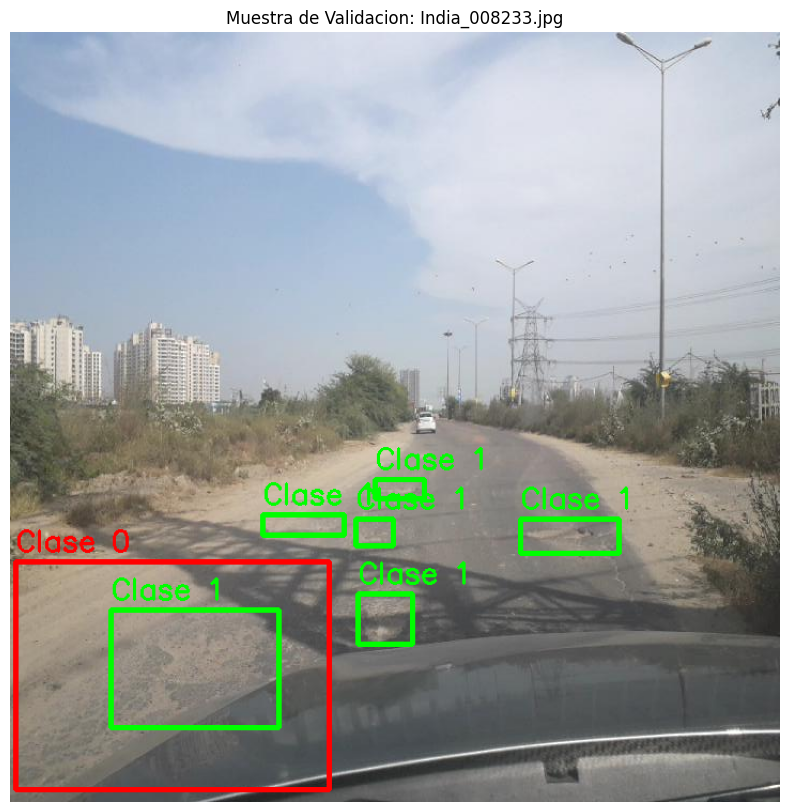

In [21]:
# Busqueda de imagenes en la capa procesada del dataset global
ruta_busqueda = "../data/processed/dataset_global/train/images/*.jpg"
imagenes_procesadas = glob.glob(ruta_busqueda)

if imagenes_procesadas:
    # Seleccion aleatoria de una imagen
    muestra_random = random.choice(imagenes_procesadas)

    # Reconstruccion de la ruta para encontrar su etiqueta correspondiente
    txt_asociado = muestra_random.replace("images", "labels").replace(".jpg", ".txt")

    print(
        f"Evaluando integridad visual del archivo: {os.path.basename(muestra_random)}"
    )
    visualizar_muestra_yolo(muestra_random, txt_asociado)
else:
    print("No se encontraron imagenes procesadas para verificar el pipeline.")